# Controlling event 
## 이벤트
### 개요
#### 일상 속의 이벤트
- 컴퓨터 키보드를 눌러 텍스트를 입력하는 것 

- 전화벨이 울려 전화가 왔음을 알리는 것

- 손을 흔들어 인사하는 것

- 전화기의 버튼을 눌러서 통화를 시작하는 것

- 리모컨을 사용하여 채널을 변경하는 것 

#### 웹에서의 이벤트
- 화면을 스크롤하는 것

- 버튼을 클릭했을 때 팝업 창이 출력되는 것

- 마우스 커서의 위치에 따라 드래그 앤 드롭하는 것

- 사용자의 키보드 입력 값에 따라 새로운 요소를 생성하는 것

- 웹에서의 모든 동작은 **이벤트 발생과 함께 한다.**

### event 객체
- event : 무언가 일어낫다는 신호, 사건 -> 모든 DOM 요소는 이러한 event를 만들어 냄

#### 'event' object
- DOM에서 이벤트가 발생했을 때 생성되는 객체

- 이벤트 종류 
    - mouse, input, keyboard, touch...

#### DOM 요소에서 event가 발생하면, 해당 event는 연결된 이벤트 처리기(event handler)에 의해 처리됨 

### event handler 
- 특정 이벤트가 발생했을 때 실행되는 함수 -> 사용자의 행동에 어떻게 반응할지를 JavaScript 코드로 표현한 것

#### .addEventListener() 
- 대표적인 이벤트 핸들러 중 하나 -> 특정 이벤트를 DOM 요소가 수신할 때마다 콜백 함수를 호출

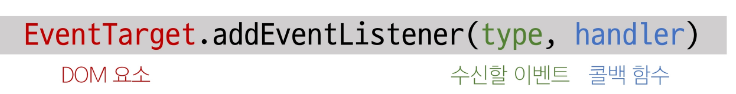

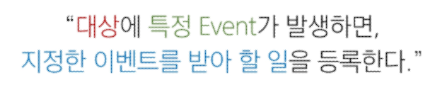

#### addEventListener의 인자

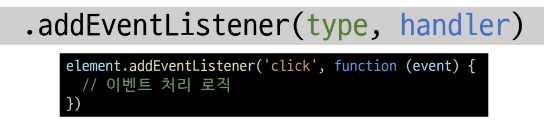

- type 
    - 수신할 이벤트 이름

    - 문자열로 작성 (ex: 'click')

- handler 
    - 발생한 이벤트 객체를 수신하는 콜백 함수

    - 이벤트 핸들러는 자동으로 event 객체를 매개변수로 받음

#### addEventListener 활용
- "버튼을 클릭하면 버튼 요소 출력하기" -> 버튼에 이벤트 처리기를 부착하여 클릭 이벤트가 발생하면 이벤트가 발생한 버튼덩보를 출력 

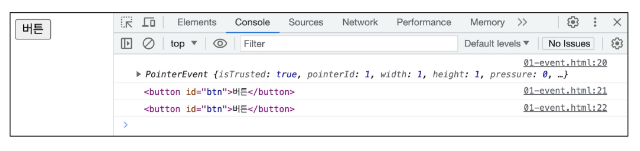

- 요소에 addEventListener를 연결하게 되면 내부의 this 값은 연결된 요소를 가리키게 됨(event 객체의 currentTarget 속성 값과 동일함)

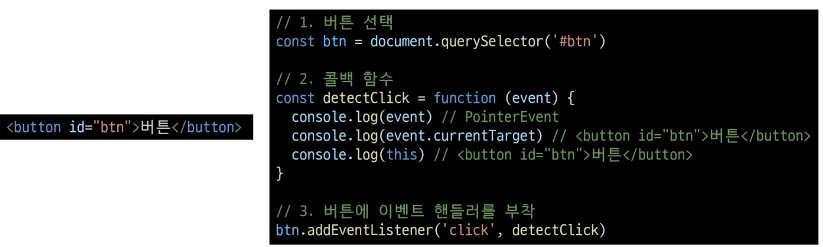

#### addEventListener의 콜백 함수 특징
- 이벤트 핸들러 내부의 this는 이벤트 리스너에 연결된 요소(currentTarget)를 가리킴

- 이벤트가 발생하면 event 객체가 생성되어 첫 번째 인자로 전달
    - event 객체가 필요없는 경우 생략 가능

- 반환 값 없음 

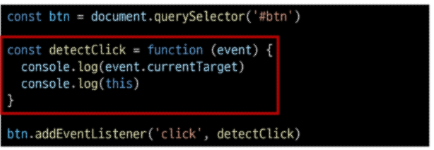

<hr>

## 버블링
#### 버블링 개요 
- form > div > p 형태의 중첩된 구조에 각각 이벤트 핸들러가 연결되어 있을 때 만약 <p> 요소를 클릭하면 어떻게 될까 

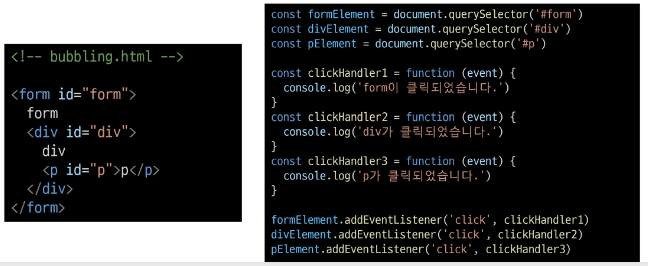


- <p> 요소만 클릭했는데도 불구하고 모든 핸들러가 동작함 -> 왜 p만을 클릭했는데 부모 요소 div와 form에 할당된 핸들러까지 동작할까?

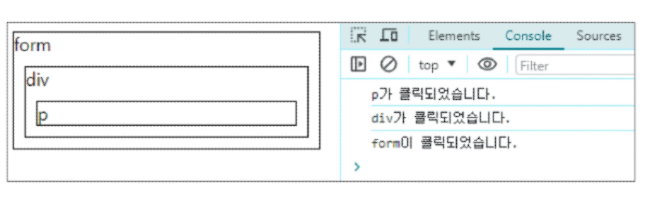

#### 버블링 (Bubbling)
- "한 요소에 이벤트가 발생하면, 이 요소에 할당된 핸들러가 동작하고, 이어서 부모 요소의 핸들러가 동작하는 현상"

- 가장 최상단의 조상 요소(document)를 만날 때까지 이 과정이 반복되면서 요소 각각에 할당된 핸들러가 동작

- 이벤트가 제일 깊은 곳에 있는 요소에서 시작해 부모 요소를 거슬러 올라가며 발생하는 것이 마치 물 속 거품과 닮았기 때문

- 최하위의 <p> 요소를 클릭하면 p -> div -> form 순서로 3개의 이벤트 핸들러가 모두 순차적으로 동작했던 것 

#### 이벤트가 정확히 어디서 발생했는지 겁근할 수 있는 방법

- event.currentTarget

- event.target

#### 'currentTarget' & 'target' 속성
- 'currentTarget' 속성
    - '현재' 요소

    - 항상 이벤트 핸들러가 연결된 요소만을 참조하는 속성

    - 'this'와 같음

- 'target' 속성
    - 이벤트가 발생한 가장 안쪽의 요소 (target)를 참조하는 속성

    - 실제 이벤트가 시작된 요소

    - 버블링이 진행되어도 변하지 않음

#### 'target' & 'currentTarget' 예시

- 세 요소 중 가장 최상위 요소인 outerouter 요소에만 핸들러가 연결

- 각 요소를 클릭했을 때 event의 target과 currentTarget의 차이 비교 

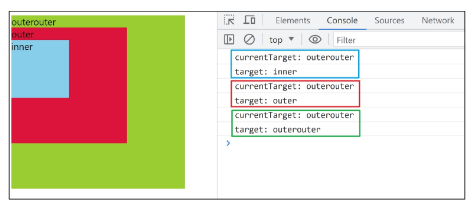

- 'currentTarget' : 핸들러가 연결된 outerouter 요소만을 가리킴

- 'target' : 실제 이벤트가 발생하는 요소를 가리킴 

- 핸들러는 outerouter에만 연결되어 있지만 하위 요소 outer와 inner를 클릭해도 해당 핸들러가 동작함 -> 클릭 이벤트가 어디서 발생했든 상관없이 outerouter까지 이벤트가 버블링되어 핸들러를 실행시키기 때문 

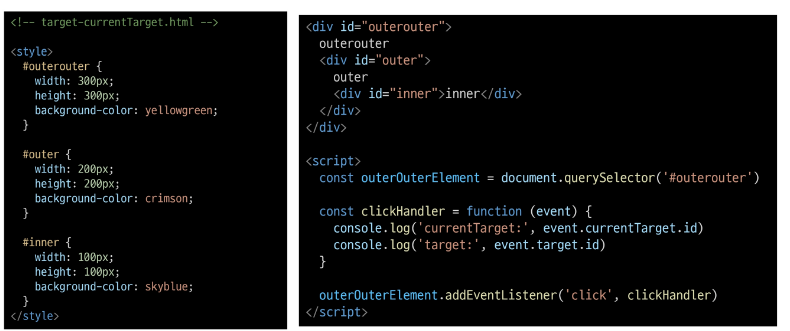

### 캡처링과 버블링
- 캡처링 (capturing) : 이벤트가 하위 요소로 전파되는 단계 (버블링과 반대)

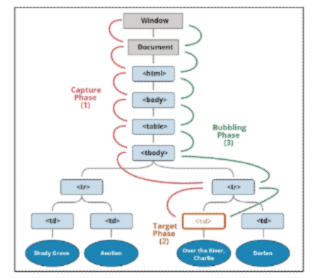

- table의 하위 요소 td를 클릭하면 이벤트는 먼저 최상위 요소부터 아래로 전파됨(캡처링)

- 실제 이벤트가 발생한 지점(event.target)에서 실행된 후 다시 위로 전파(버블링)
    - 이 전파 과정에서 상위 요소에 할당된 이벤트 핸들러들이 호출되는 것

- 캡처링은 실제 개발자가 다루는 경우가 거의 없으므로 버블링에 집중하기

### 버블링의 필요성

#### 버블링이 필요한 이유

- 만약 다음과 같이 각자 다른 동작을 수행하는 버튼이 여러 개가 있다고 가정

- 그렇다면 각 버튼마다 서로 다른 이벤트 핸들러를 할당해야 할까? 

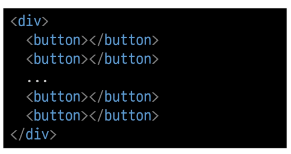

- 해결 : 각 버튼의 **공통 조상인 div 요소에 이벤트 핸들러 단 하나만 할당**하기 

- 요소의 공통 조상에 이벤트 핸들러를 단 하나만 할당하면, 여러 버튼 요소에서 발생하는 이벤트를 한꺼번에 다룰 수 있음

- 공통 조상에 할당한 핸들러에서 event.target을 이용하면 실제 어떤 버튼에서 이벤트가 발생했는지 알 수 있기 때문 

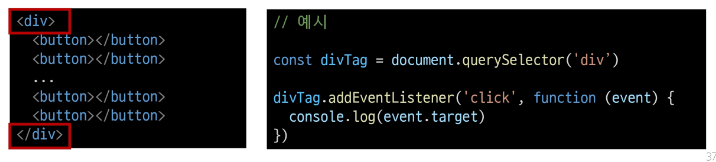

<hr>

## event handler 활용

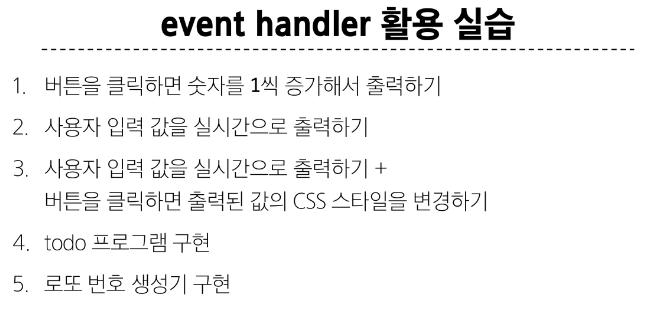

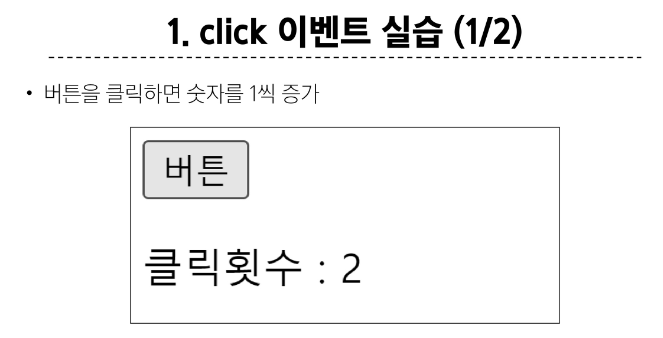

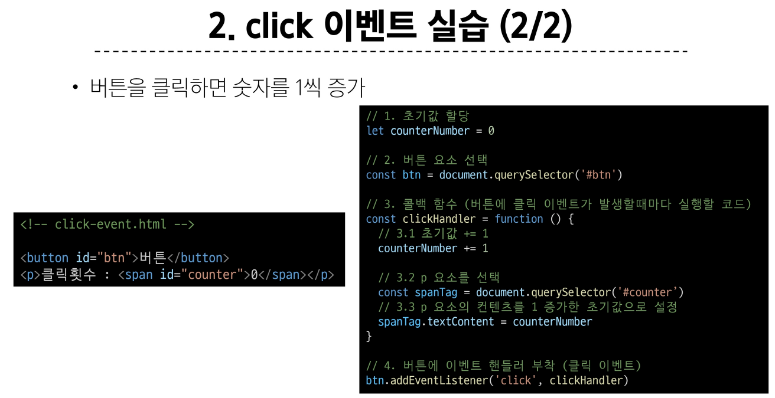

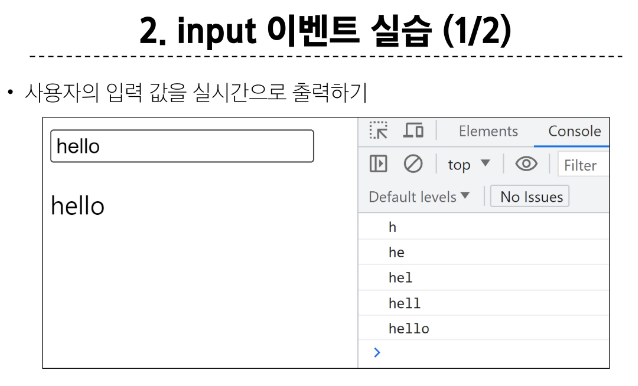

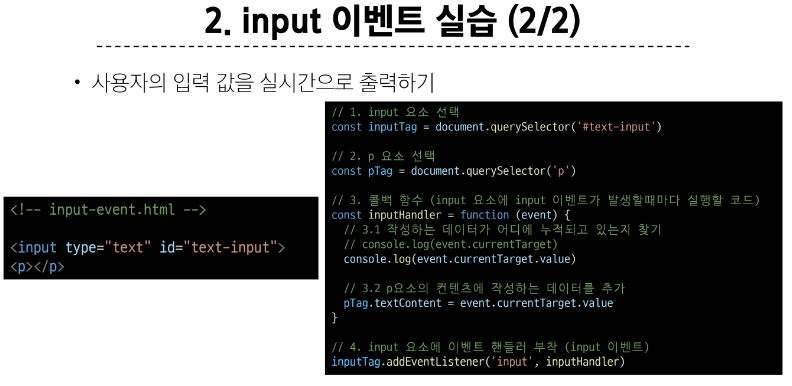

#### 'currendTarget' 주의사항
- console.log()로 event 객체를 출력할 경우 currentTarget 키의 값은 nuil을 가짐

- currentTarget은 이벤트가 처리되는 동안에만 사용할 수 있기 때문에

- 대신 console.log(event.currentTarget)을 사용하여 콘솔에서 확인 가능

- currentTarget 이후의 속성 값들은 **'target'을 참고해서 사용하기**

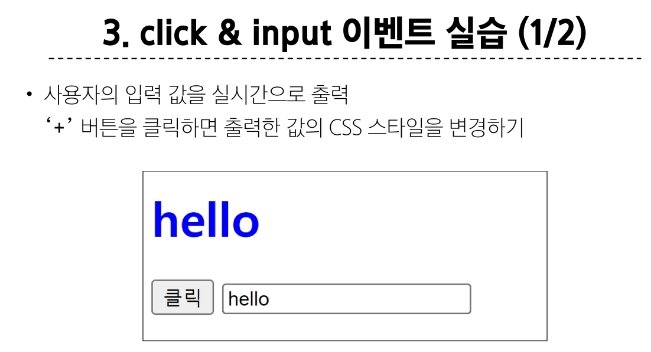

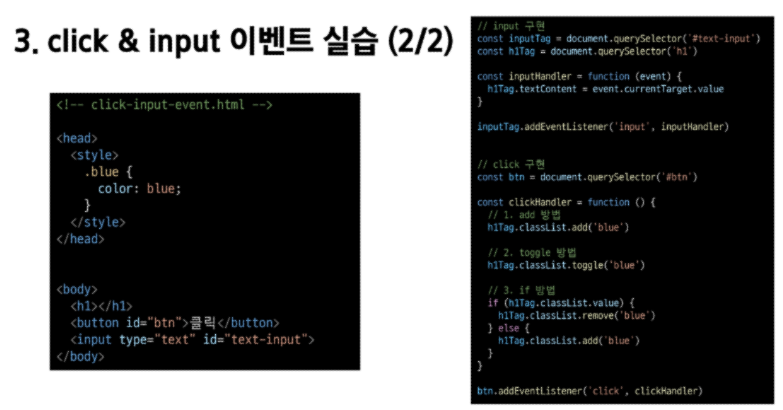

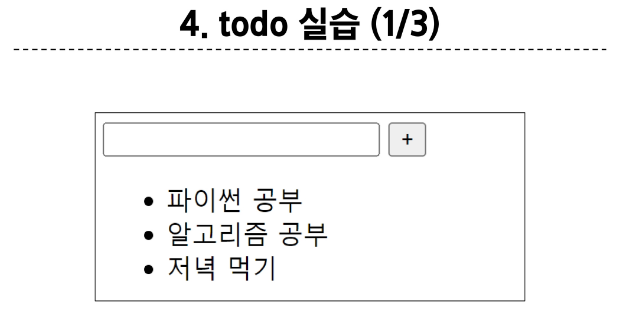

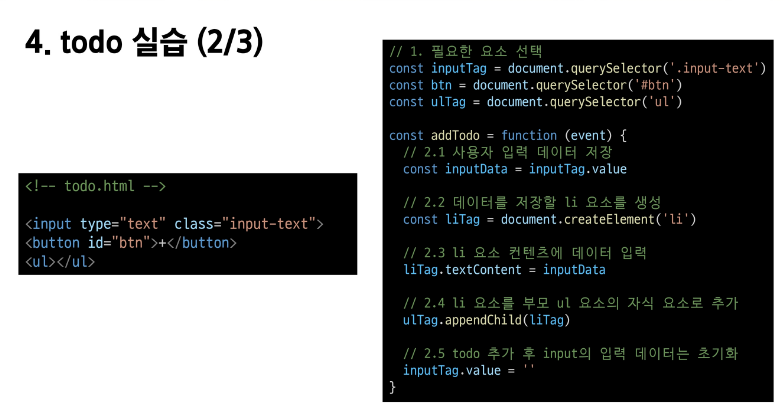

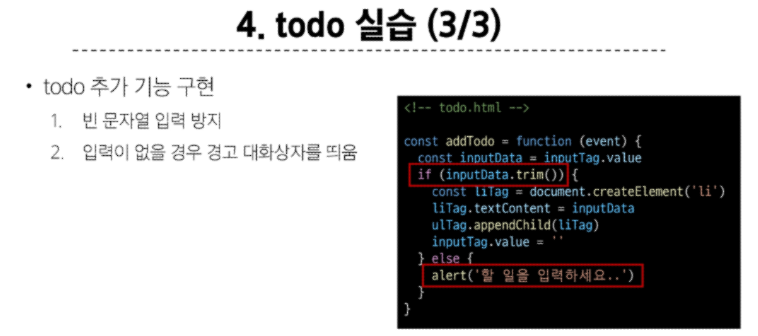

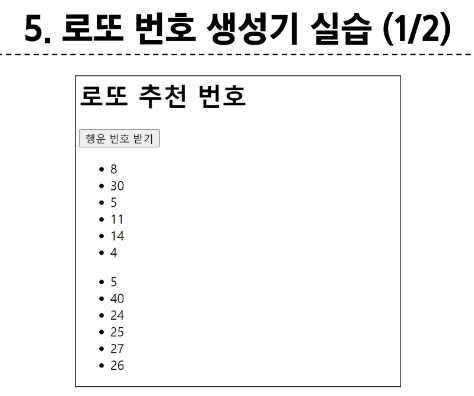

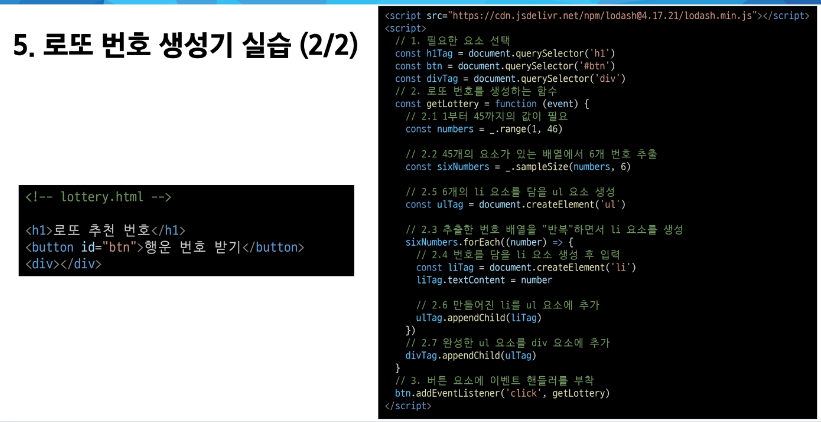

### 이벤트 기본 동작 취소하기
- HTML의 각 요소가 기본적으로 가지고 있는 이벤트가 때로는 방해가 되는 경우가 있어 이벤트의 기본 동작을 취소할 필요가 있음

- 예시
    - form 요소의 제출 이벤트를 취소하여 페이지 새로고침을 막을 수 있음

    - a 요소를 클릭할 때 페이지 이동을 막고 추가 로직을 수행할 수 있음

#### .preventDefault() 
- 해당 이벤트에 대한 기본 동작을 실행하지 않도록 지정

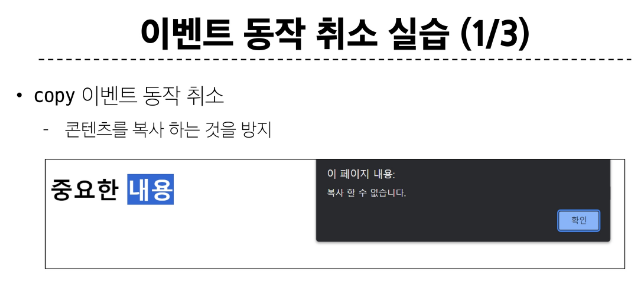

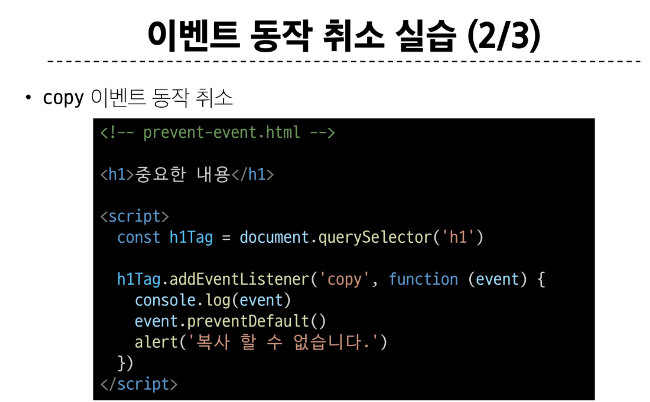

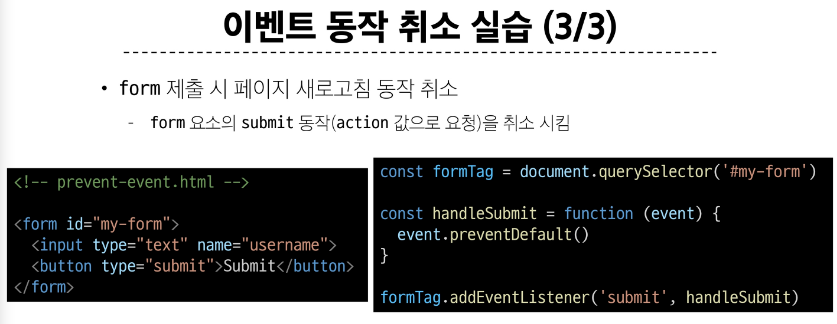

<hr>

## 참고
### addEventListener와 화살표 함수 관계 
#### addEventListener에서의 화살표 함수 주의사항

- 화살표 함수는 자신만의 this를 생성하지 않음

- 대신, 화살표 함수는 정의된 곳의 상위 스코프의 this를 그대로 사용

- 대부분의 경우, 이는 전역 객체(브라우저에서는 window)를 가리키게 됨

- 해결책
    1. 일반 함수로 사용하기

    2. 화살표 함수일 경우 event.currentTarget을 사용하기 

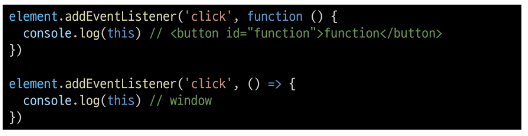